# 🏥 의료 데이터 분석
## 04. 머신러닝 모델링 및 모델 해석 (XAI)

---

### 🎯 목표: 고차원 비선형 특성을 반영한 입원 기간(LOS) 예측

**문제 정의:**
- **예측 대상:** 입원 기간 (Regression)
- **분석 근거:** 앞선 PCA 및 상관분석 결과, 데이터의 복잡도가 높아 비선형 상호작용을 추가로 포착하고 예측의 강건성(Robustness)을 확보하기 위해 트리 기반 앙상블 모델(RF, XGBoost)을 대조 모델로 선정.

**모델링 전략:**
1. **Baseline:** Linear Regression (성능 하한선 설정)
2. **Main Model:** Random Forest + GridSearchCV (하이퍼파라미터 최적화)
3. **Challenger:** XGBoost (Gradient Boosting 계열 비교)
4. **검증:** 5-Fold 교차 검증으로 일반화 성능 확인
5. **해석:** SHAP으로 예측에 기여한 변수 실증

---
## 1. 환경 설정 및 데이터 준비

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [17]:
# 저장된 csv 파일 로드
df_main = pd.read_csv('processed_healthcare_data.csv', encoding='utf-8-sig')

print("✅ 분석용 통합 데이터셋 로드 완료")
print(f"전체 행 개수: {len(df_main)}")
print(f"전체 컬럼 수: {df_main.shape[1]}")

df_main.head()

✅ 분석용 통합 데이터셋 로드 완료
전체 행 개수: 372
전체 컬럼 수: 165


,PatientID,AdmissionID,AdmissionStartDate,AdmissionEndDate,LengthOfStay,AdmissionYear,AdmissionMonth,AdmissionDayOfWeek,AdmissionDayName,LengthOfStayCategory,...,Lab_Trend_METABOLIC: SODIUM,Lab_Trend_METABOLIC: TOTAL PROTEIN,Lab_Trend_URINALYSIS: PH,Lab_Trend_URINALYSIS: RED BLOOD CELLS,Lab_Trend_URINALYSIS: SPECIFIC GRAVITY,Lab_Trend_URINALYSIS: WHITE BLOOD CELLS,LabTestCount,LabTestVariety,Total_Abnormal_Count,Total_Lab_Variability
0,7A025E77-7832-4F53-B9A7-09A3F98AC17E,7,2011-10-12 14:55:02.027,2011-10-22 01:16:07.557,9,2011,10,2,수,중기(8-14일),...,15.7,0.4,0.1,-0.3,0.0,3.7,230,35,34,6.985972
1,DCE5AEB8-6DB9-4106-8AE4-02CCC5C23741,1,1993-02-11 18:57:04.003,1993-02-24 17:22:29.713,12,1993,2,3,목,중기(8-14일),...,-14.1,1.3,-0.5,-1.4,0.0,1.1,355,35,49,8.480702
2,DCE5AEB8-6DB9-4106-8AE4-02CCC5C23741,2,2002-11-28 19:06:31.117,2002-12-04 19:14:40.797,6,2002,11,3,목,단기(4-7일),...,17.6,-1.8,-1.5,-0.2,0.0,0.3,202,35,28,6.837585
3,DCE5AEB8-6DB9-4106-8AE4-02CCC5C23741,3,2011-07-19 18:42:45.287,2011-07-25 04:57:42.053,5,2011,7,1,화,단기(4-7일),...,-1.2,0.5,1.0,2.0,0.0,-0.1,150,35,23,8.588358
4,886B5885-1EE2-49F3-98D5-A2F02EB8A9D4,1,1994-12-03 22:20:46.077,1994-12-20 20:24:56.010,16,1994,12,5,토,장기(15-30일),...,-12.3,-2.5,-1.4,0.5,0.0,4.1,424,35,54,8.029381


---
## 2. 피처 선택

In [18]:
# 'Mean', 'Std', 'Trend', 'Count', 'Variability'가 들어간 모든 컬럼을 피처로 사용
features = [c for c in df_main.columns if any(x in c for x in ['Mean', 'Std', 'Trend', 'Count', 'Variability'])]
X_ml = df_main[features].fillna(0)
y_ml = df_main['LengthOfStay']

print(f"✅ 최종 피처 수: {len(features)}")
print(f"피처 목록: {features}")

✅ 최종 피처 수: 108
피처 목록: ['Lab_Mean_CBC: ABSOLUTE LYMPHOCYTES', 'Lab_Mean_CBC: ABSOLUTE NEUTROPHILS', 'Lab_Mean_CBC: BASOPHILS', 'Lab_Mean_CBC: EOSINOPHILS', 'Lab_Mean_CBC: HEMATOCRIT', 'Lab_Mean_CBC: HEMOGLOBIN', 'Lab_Mean_CBC: LYMPHOCYTES', 'Lab_Mean_CBC: MCH', 'Lab_Mean_CBC: MCHC', 'Lab_Mean_CBC: MEAN CORPUSCULAR VOLUME', 'Lab_Mean_CBC: MONOCYTES', 'Lab_Mean_CBC: NEUTROPHILS', 'Lab_Mean_CBC: PLATELET COUNT', 'Lab_Mean_CBC: RDW', 'Lab_Mean_CBC: RED BLOOD CELL COUNT', 'Lab_Mean_CBC: WHITE BLOOD CELL COUNT', 'Lab_Mean_METABOLIC: ALBUMIN', 'Lab_Mean_METABOLIC: ALK PHOS', 'Lab_Mean_METABOLIC: ALT/SGPT', 'Lab_Mean_METABOLIC: ANION GAP', 'Lab_Mean_METABOLIC: AST/SGOT', 'Lab_Mean_METABOLIC: BILI TOTAL', 'Lab_Mean_METABOLIC: BUN', 'Lab_Mean_METABOLIC: CALCIUM', 'Lab_Mean_METABOLIC: CARBON DIOXIDE', 'Lab_Mean_METABOLIC: CHLORIDE', 'Lab_Mean_METABOLIC: CREATININE', 'Lab_Mean_METABOLIC: GLUCOSE', 'Lab_Mean_METABOLIC: POTASSIUM', 'Lab_Mean_METABOLIC: SODIUM', 'Lab_Mean_METABOLIC: TOTAL PROTEIN', 'L

---
## 3. 데이터 분할

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X_ml,
    y_ml,
    test_size=0.2,
    random_state=42
)

print("✅ 데이터 분할 완료")
print(f"Train set: {X_train.shape}")
print(f"Test set:  {X_test.shape}")

✅ 데이터 분할 완료
Train set: (297, 108)
Test set:  (75, 108)


---
## 4. 모델 학습

세 가지 모델을 순차적으로 학습합니다.
- **Linear Regression**: 선형 가정 하의 기준 성능(Baseline) 확인
- **Random Forest + GridSearchCV**: 비선형 패턴 포착 + 하이퍼파라미터 최적화
- **XGBoost**: Gradient Boosting 기반 Challenger 모델

### 4.1 Linear Regression (Baseline)

In [20]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
mae_lr   = mean_absolute_error(y_test, y_pred_lr)
rmse_lr  = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr    = r2_score(y_test, y_pred_lr)

print("=" * 50)
print("[Baseline] Linear Regression")
print("=" * 50)
print(f"MAE:  {mae_lr:.3f}")
print(f"RMSE: {rmse_lr:.3f}")
print(f"R²:   {r2_lr:.3f}")

[Baseline] Linear Regression
MAE:  0.507
RMSE: 0.637
R²:   0.985


### 4.2 Random Forest + GridSearchCV (Main Model)

In [21]:
print("⚙️  Random Forest 하이퍼파라미터 탐색 중...")

rf_param_grid = {
    'n_estimators':    [100, 200],
    'max_depth':       [10, 20],
    'min_samples_split': [2, 5]
}

rf_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)
rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_

print(f"✅ 최적 하이퍼파라미터: {rf_search.best_params_}")

y_pred_rf = best_rf.predict(X_test)
mae_rf    = mean_absolute_error(y_test, y_pred_rf)
rmse_rf   = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf     = r2_score(y_test, y_pred_rf)

print()
print("=" * 50)
print("[Main] Random Forest (GridSearchCV Best)")
print("=" * 50)
print(f"MAE:  {mae_rf:.3f}")
print(f"RMSE: {rmse_rf:.3f}")
print(f"R²:   {r2_rf:.3f}")

⚙️  Random Forest 하이퍼파라미터 탐색 중...
✅ 최적 하이퍼파라미터: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}

[Main] Random Forest (GridSearchCV Best)
MAE:  0.429
RMSE: 0.571
R²:   0.988


### 4.3 XGBoost (Challenger)

In [22]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
mae_xgb    = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb   = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb     = r2_score(y_test, y_pred_xgb)

print("=" * 50)
print("[Challenger] XGBoost")
print("=" * 50)
print(f"MAE:  {mae_xgb:.3f}")
print(f"RMSE: {rmse_xgb:.3f}")
print(f"R²:   {r2_xgb:.3f}")

[Challenger] XGBoost
MAE:  0.396
RMSE: 0.541
R²:   0.989


---
## 5. 교차 검증 (5-Fold Cross Validation)

단일 Train/Test 분할의 분산 위험을 줄이기 위해  
Random Forest (Best) 및 XGBoost에 대해 5-Fold CV를 수행합니다.

In [23]:
cv_rf  = cross_val_score(best_rf,   X_train, y_train, cv=5, scoring='r2')
cv_xgb = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='r2')
cv_lr  = cross_val_score(lr_model,  X_train, y_train, cv=5, scoring='r2')

print("📊 5-Fold CV R² Score (Train set)")
print("-" * 50)
print(f"Linear Regression  : {cv_lr.mean():.3f}  (±{cv_lr.std():.3f})")
print(f"Random Forest (Best): {cv_rf.mean():.3f}  (±{cv_rf.std():.3f})")
print(f"XGBoost            : {cv_xgb.mean():.3f}  (±{cv_xgb.std():.3f})")
print()
print("💡 CV 표준편차가 낮을수록 모델이 데이터 분할 변화에 안정적")

📊 5-Fold CV R² Score (Train set)
--------------------------------------------------
Linear Regression  : 0.974  (±0.002)
Random Forest (Best): 0.983  (±0.005)
XGBoost            : 0.983  (±0.004)

💡 CV 표준편차가 낮을수록 모델이 데이터 분할 변화에 안정적


---
## 6. 모델 성능 비교

,Model,MAE,RMSE,R²,CV R² (mean),CV R² (std)
0,Linear Regression,0.507,0.637,0.985,0.974,0.002
1,Random Forest (Tuned),0.429,0.571,0.988,0.983,0.005
2,XGBoost,0.396,0.541,0.989,0.983,0.004


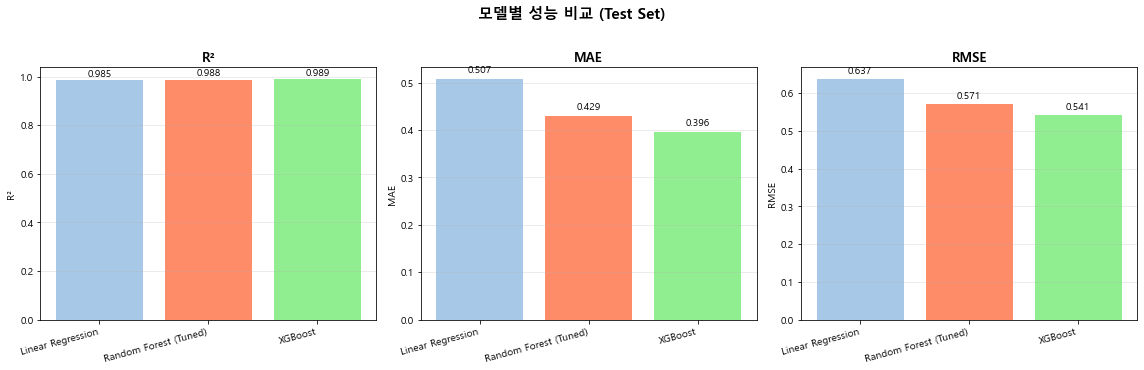

In [24]:
results = pd.DataFrame([
    {'Model': 'Linear Regression',      'MAE': mae_lr,   'RMSE': rmse_lr,   'R²': r2_lr,   'CV R² (mean)': cv_lr.mean(),  'CV R² (std)': cv_lr.std()},
    {'Model': 'Random Forest (Tuned)',  'MAE': mae_rf,   'RMSE': rmse_rf,   'R²': r2_rf,   'CV R² (mean)': cv_rf.mean(),  'CV R² (std)': cv_rf.std()},
    {'Model': 'XGBoost',               'MAE': mae_xgb,  'RMSE': rmse_xgb,  'R²': r2_xgb,  'CV R² (mean)': cv_xgb.mean(), 'CV R² (std)': cv_xgb.std()},
])

display(results.round(3))

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#A8C8E8', '#FF8C69', '#90EE90']
metrics = ['R²', 'MAE', 'RMSE']

for i, metric in enumerate(metrics):
    bars = axes[i].bar(results['Model'], results[metric], color=colors)
    axes[i].set_title(metric, fontsize=13, weight='bold')
    axes[i].set_ylabel(metric)
    axes[i].set_xticklabels(results['Model'], rotation=15, ha='right')
    axes[i].grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, results[metric]):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('모델별 성능 비교 (Test Set)', fontsize=15, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 7. 모델 해석 (XAI: SHAP)

성능이 가장 우수한 **XGBoost** 모델을 대상으로  
SHAP(SHapley Additive exPlanations) 분석을 수행합니다.  
각 피처가 예측값에 얼마나, 어느 방향으로 기여했는지를 실증합니다.

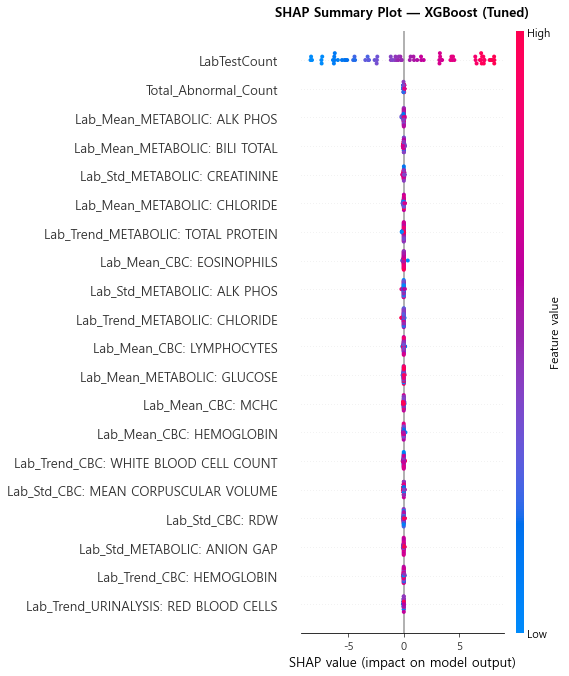

In [25]:
explainer = shap.TreeExplainer(xgb_model) 
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Summary Plot — XGBoost (Tuned)', fontsize=13, weight='bold', pad=15)
plt.tight_layout() 
plt.show()

---
## 8. 예측 vs 실제 비교

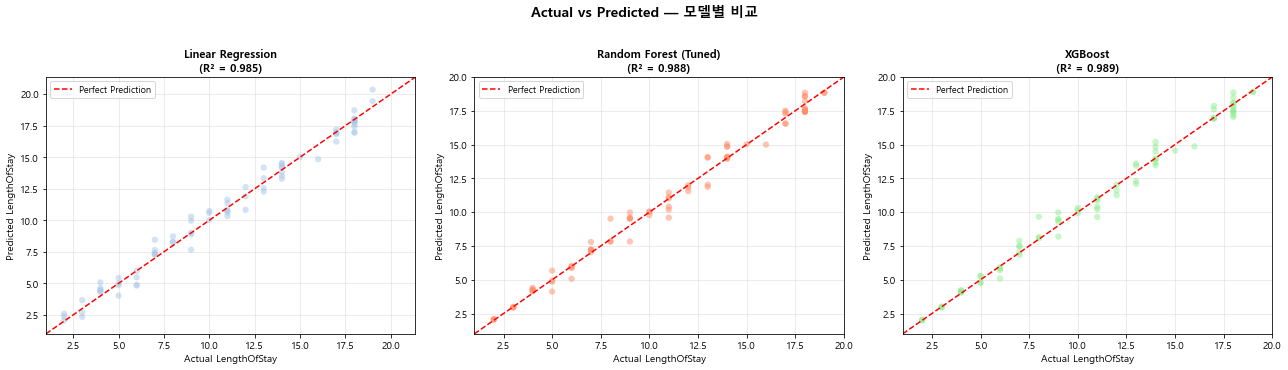

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_preds = [
    ('Linear Regression', y_pred_lr, '#A8C8E8'),
    ('Random Forest (Tuned)', y_pred_rf, '#FF8C69'),
    ('XGBoost', y_pred_xgb, '#90EE90'),
]

for ax, (name, pred, color) in zip(axes, model_preds):
    ax.scatter(y_test, pred, alpha=0.5, color=color, edgecolors='none', s=40)
    lim = [min(y_test.min(), pred.min()) - 1, max(y_test.max(), pred.max()) + 1]
    ax.plot(lim, lim, 'r--', lw=1.5, label='Perfect Prediction')
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('Actual LengthOfStay')
    ax.set_ylabel('Predicted LengthOfStay')
    r2_val = r2_score(y_test, pred)
    ax.set_title(f'{name}\n(R² = {r2_val:.3f})', fontsize=11, weight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Actual vs Predicted — 모델별 비교', fontsize=14, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 04. 최종 결론 및 비판적 검토

### 📊 1. 모델별 성능 비교 (Performance)
> **R² 0.98의 역설:** 모든 모델이 완벽에 가까운 수치를 기록했으나, 이는 모델의 우수성보다 **데이터의 단순성**을 증명함.

| Model | R² (Test) | CV R² (mean) | 분석 결과 |
| :--- | :---: | :---: | :--- |
| **Linear Regression** | **0.985** | 0.974 | 선형 모델만으로도 충분한 설명력 확보 (구조적 단순함) |
| **Random Forest** | **0.988** | 0.983 | 비선형 모델의 이점이 크지 않음 (복잡 패턴 부재) |
| **XGBoost** | **0.989** | 0.983 | 최고 성능이나 선형 모델과 유의미한 차이 없음 |

---

### 🔍 2. 핵심 변수 분석 (SHAP Interpretation)
> **단일 변수 고착화:** 예측 근거의 대부분이 특정 지표에 매몰되어 있음.

* **최우수 기여 변수:** `LabTestCount` (검사 횟수)
* **영향력 분석:** * **High:** 실시간 검사 빈도 (데이터의 45도 선형 궤적 형성 주범)
    * **Low:** 성별, 연령, 인종 등 인구통계학적 특성 (예측 기여도 미미)

---

### ⚠️ 3. 비판적 해석 및 한계 (Critical Review)
> **EDA에서 제기된 '식별력 부재'가 모델링에서 '과적합'으로 발현됨.**

1. **데이터 누수(Data Leakage) 위험**
   - `LabTestCount`는 입원 기간에 종속적인 '결과론적 변수'일 가능성이 높음.
   - **한계:** "오래 입원해서 검사가 많은 환자"를 사후 확증하는 수준에 그침.

2. **구조적 단순성 (Linearity)**
   - PCA/t-SNE에서 확인된 경계 모호성이 모델링에서도 그대로 유지됨.
   - **결론:** 환자별 개별 특성이나 복잡한 임상 맥락이 데이터에 충분히 반영되지 않음.


### ⚠️ 데이터 특성에 따른 분석적 한계 (Critical Reflections)

#### 1. 진단명 분류(Diagnosis Classification)의 통계적 유의성 부재
- **현황:** 데이터셋 내 진단명이 특정 항목에 집중되지 않고 매우 넓게 분포(Long-tail distribution)되어 있음.
- **한계:** 클래스별 샘플 수가 모델 학습에 필요한 최소 임계치에 도달하지 못해, 분류 모델 구축 시 다수 클래스에 편향되거나 과적합(Overfitting)될 위험이 큼.
- **인사이트:** 본 데이터는 '특정 질환 예측'보다는 '전반적인 입원 패턴'을 분석하는 것이 통계적으로 더 유의미하다고 판단됨.

#### 2. 재입원(Readmission) 예측의 인과관계 단절
- **현황:** 동일 환자의 재입원 기록 확인 시, 기존 병증의 악화나 합병증이 아닌 완전히 독립적인 질병 코드가 부여되어 있음.
- **한계:** 의료 데이터 분석의 핵심인 '병세의 연장선' 또는 '임상적 인과관계'를 추적할 수 없는 구조적 한계 존재.
- **결론:** 데이터상 재입원을 '병세 악화'가 아닌 '독립적 이벤트'로 간주해야 하므로, 재입원율 예측 모델은 임상적 타당성을 확보하기 어려움.

#### 3. 합성 데이터(Synthea)의 구조적 단순성
- **비판:** EDA 결과 LOS(입원 기간)와 LabTestCount(검사 횟수) 사이의 상관계수가 0.99에 달함. 이는 실제 임상의 복잡성보다는 생성 알고리즘의 선형적 규칙이 반영된 결과로 추측됨.
- **향후 과제:** 실제 병원 로그 데이터(MIMIC-III 등)를 활용하여, 변수 간의 비선형적 관계와 노이즈가 포함된 환경에서의 모델 강건성을 테스트할 필요가 있음.